In [2]:
#PArt A
#task 1
import pandas as pd
import matplotlib.pyplot as plt
#importing the pandas library  and matplot

ratings = pd.read_csv('data/ratings.csv') #rating df
movies = pd.read_csv('data/movies.csv') #movies df
#reading the csv files and putting them into dataframes
ratings




,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [3]:
num_users = ratings['userId'].nunique() #how many cells are filled by info unique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

total_possible_cells = num_users * num_movies#total number of possible rating
sparsity = 1.0 - (num_ratings / total_possible_cells) #describe how empty is our matrix

print(f"Users: {num_users}, Movies: {num_movies}, Ratings: {num_ratings}")
print(f"Matrix Sparsity: {sparsity:.2%}")

Users: 610, Movies: 9724, Ratings: 100836
Matrix Sparsity: 98.30%


In [4]:
#task 13
test_df = ratings.groupby('userId').sample(frac=0.2, random_state=42) #this allows us to pick only 20% of rating for each user, random state mean we will get the same result every time
train_df = ratings.drop(test_df.index)#removes the 20% of test data from the list
test_df#tail and head only


,userId,movieId,rating,timestamp
219,1,3578,5.0,964980668
66,1,1127,4.0,964982513
9,1,157,5.0,964984100
170,1,2617,2.0,964982588
15,1,260,5.0,964981680
...,...,...,...,...
99701,610,2976,4.0,1479542190
99935,610,5956,3.5,1479542164
100011,610,7173,3.0,1493847204
100197,610,45722,3.5,1493844944


In [5]:
train_matrix = pd.pivot_table(
    train_df, 
    values='rating', 
    index='userId', 
    columns='movieId'
)
#making a 2d matrix form of the raw data from the data-
#frame given colomns with the movie ids and the rows with the user ids
train_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


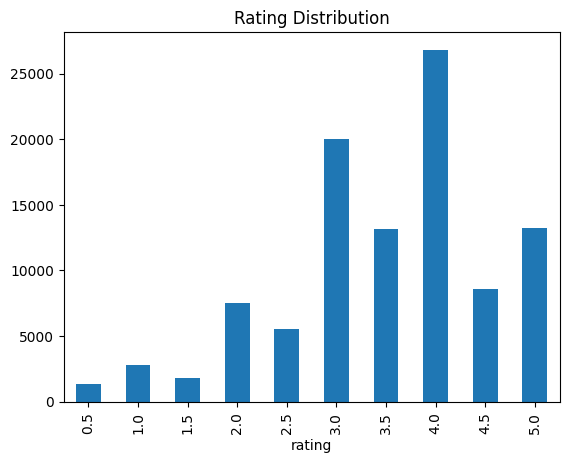

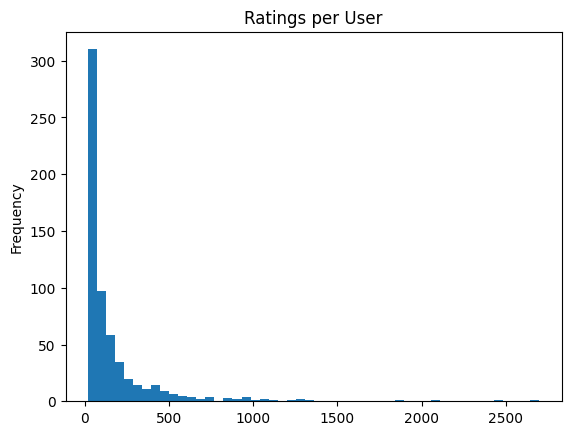

In [6]:
# 1. Distribution of rating values (e.g., how many 4.0s vs 1.0s)
ratings['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.show()
#rating['rating'] makes us work on the rating column only 
# #value counts counts how many times each score appeared and then we sort and plot
# 2. Distribution of how many ratings each user submitted
ratings.groupby('userId').size().plot(kind='hist', bins=50, title='Ratings per User')
plt.show()
#here we groupby we group each user alone and then we take the number of ratings that they recorded

In [8]:
#Part B
#task 5
import numpy as np
#this is an important function that allows us to get 2 vectors of movie a and b and their rating data or 2 for user a and b and their rating data

def get_co_rated(matrix, a, b, axis='index'):    
    # Extract the raw vectors (rows for users, columns for items)
    if axis == 'index':
        vec_a = matrix.loc[a]
        vec_b = matrix.loc[b] #rows user a rating and user b rating every individual rating the peron a and person b made
    else:
        vec_a = matrix[a]
        vec_b = matrix[b]#colomns movie a and movie b every rating for the move a and b fromo different users
        b
    # Combine them into a temporary 2-column table and drop any row with a NaN
    temp_df = pd.DataFrame({'a': vec_a, 'b': vec_b}).dropna()#drops the nAn values so the program dont crash while comparing
    
    # Extract the clean columns back out as raw NumPy arrays
    return temp_df['a'].values, temp_df['b'].values



In [9]:
#task 6
def euclidean_similarity(vec1, vec2):
    # Rule: If they share fewer than 2 movies, similarity is undefined
    if len(vec1) < 2: return np.nan 
    
    # Vectorized math replaces a for loop summing (vec1[i] - vec2[i])^2 
    distance = np.sqrt(np.sum((vec1 - vec2)**2))# this is the equation for it higher mean higher similarity
    return 1 / (1 + distance)

In [10]:
#task 7
def cosine_similarity(vec1, vec2):
    if len(vec1) < 2: return np.nan
    
    numerator = np.dot(vec1, vec2)
    denominator = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    #linlag sum of squares and taken the sqrt of them
    
    if denominator == 0: return 0.0
    return numerator / denominator #implementing the formula only

In [11]:
#task 8
def pearson_similarity(vec1, vec2):
    if len(vec1) < 2: return np.nan
    
    # Mean-center the data to remove the "generous/harsh rater" bias[cite: 1]
    vec1_centered = vec1 - np.mean(vec1)
    vec2_centered = vec2 - np.mean(vec2)
    
    numerator = np.dot(vec1_centered, vec2_centered)
    denominator = np.linalg.norm(vec1_centered) * np.linalg.norm(vec2_centered) #linlag.norm is the sum of squared values in the array and then we take the square root value for it
    
    if denominator == 0: return 0.0
    return numerator / denominator

In [12]:
# sanity test
import numpy as np

# The exact "generous vs. harsh rater" arrays from the assignment[cite: 1]
user_a = np.array([5, 4, 5, 3])
user_b = np.array([3, 2, 3, 1])

print(f"Euclidean Similarity: {euclidean_similarity(user_a, user_b):.3f}")
print(f"Cosine Similarity: {cosine_similarity(user_a, user_b):.3f}")
print(f"Pearson Similarity: {pearson_similarity(user_a, user_b):.3f}")

Euclidean Similarity: 0.200
Cosine Similarity: 0.987
Pearson Similarity: 1.000


#so the euclidean similarity depends on the actual rating between the users so it fails to see the pattern between them its distance dependant the distance of user a and user b in this  example is 2 so it gives us a low value

#cosine similarity compares the angle of each vector but it fails to adjust for the constant offset so it is not a perfect 1.0

#pearson similarity gives us a perfect 1.0 because it focuses on the distance between the values and the mean for each value elimiting the constant shift so this is why the pearson similarity model is the best to use for the movie reccomendation system

In [13]:
#Part C User based colloborative filtering
#task 9

def find_k_nearest_users(matrix,target_user,k,similarityfn):
    similarities=[]#the array we put the users and the similarity value that we get from the up functions
    for user in matrix.index: #rows
        if user == target_user: #prevents comparing the targeted user with himself
            continue
        vec_target, vec_other =get_co_rated(matrix, target_user, user,axis='index')
        #unpacking the 2 vectors of the target user and the other user
        #we just get their overlapping ratings in a matrix using the co rated function
        sim = similarityfn(vec_target,vec_other)
        if not np.isnan(sim):
            similarities.append((user, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)  #sortin the list of tuples (user,sim value) in a descending order according to the sim value

    return similarities[:k]


#this function loops in the whole matrix of users and gets us a list of users with a similar taste in movies to our targeted user
#key=lambda x: x[1] is the second value in the tuple 
#the k value is the top k values in the list of tuples (k nn)


In [14]:
#task 10 predict the rating user based
#this function predicts  what the target user will rate a movie that he havent seen from knn 
def predict_rating_user_based(matrix, target_user, target_item, k, similarityfn):
    nearest_users = find_k_nearest_users(matrix, target_user, k, similarityfn)
    numerator = 0.0
    denominator = 0.0 
    for user, sim in nearest_users:
        rating = matrix.loc[user, target_item] #--takes the rating of a single movie from a single user
        
        # Only include neighbors who actually rated the target movie
        if not np.isnan(rating): # -- discards the neighbors who hadnt rated the movie
            numerator += sim * rating # -- adds the weight of the rating to the numerator
            
            denominator += np.abs(sim)#just scales rating to its normal value by dividing the similarity value
    if denominator == 0: #if none of the users had rated the targeted movie
        return None
        
    return numerator / denominator

In [15]:
#Part D: Item-Based Collaborative Filtering
#task 11
def find_k_nearest_items(matrix, target_item, k, similarityfn):
    similarities = []
    for item in matrix.columns: 
        if item == target_item: #prevents comparing targeted item with itself
            continue
            
        # CHANGE 2: Set axis='columns' to extract vertical arrays
        vec_target, vec_other = get_co_rated(matrix, target_item, item, axis='columns')
        
        sim = similarityfn(vec_target, vec_other)
        
        if not np.isnan(sim):
            similarities.append((item, sim))
            
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]

def predict_rating_item_based(matrix, target_user, target_item, k, similarityfn):
    # Get the closest movies to the target movie
    nearest_items = find_k_nearest_items(matrix, target_item, k, similarityfn)
    
    numerator = 0.0
    denominator = 0.0
    
    for item, sim in nearest_items:
        # Check what the TARGET USER rated these similar movies
        rating = matrix.loc[target_user, item]
        
        if not np.isnan(rating):
            numerator += sim * rating
            denominator += np.abs(sim)
            
    if denominator == 0:
        return None
        
    return numerator / denominator


#task 12
i reused the same logic and everything from part c except for extracting the  knn we extracted them from the coloumns not rows based on the the movies 
the main differnce in part d now is that we look at similar movies and predict what the user will predict in according to according to the movies similarity not users simularity

In [16]:
#Part E: Evaluation
#TASK 13 ALREADY DONE earliear in the noteboook
def train_test_split_ratings(ratings_df, test_fraction=0.2):
    
    #-- groups the users by clustering them and then we take randomly 20% of each user rating to be used as test data
    test_df = ratings_df.groupby('userId').sample(frac=test_fraction, random_state=42)
    
    # 2. Remove those exact test rows from the main dataset to create the training set
    train_df = ratings_df.drop(test_df.index)
    #that drops the row from the test data from the main data frame and creates a new data frame with the remaining 80% of the data 
    
    # 3. Pivot the 2D matrix using ONLY the 80% training data
    train_matrix = pd.pivot_table(
        train_df, 
        values='rating', 
        index='userId', 
        columns='movieId'
    )
    #matrix 2d(userId, movieId) values are the ratings
    
    return train_matrix, test_df

# Execute it immediately on the raw ratings loaded earlier 
train_matrix, test_df = train_test_split_ratings(ratings)

In [17]:
#task 14
#this function is to evaluate the quality of the guesses that the model made
#by getting the rmse,mae and fraction of none values
def evaluate(matrix, test_df, k, similarity_fn, method):
    squared_errors = []
    absolute_errors = []
    none_count = 0
    total_predictions = len(test_df)
    
    # loop through each row in the test set and make predictions to be compared with the actual ratings
    for _, row in test_df.iterrows():
        user = row['userId']
        item = row['movieId']
        true_rating = row['rating']
        
        # Edge case: If the test set contains a user or movie that got completely 
        # filtered out of the training matrix, we cannot predict it.
        if user not in matrix.index or item not in matrix.columns:
            none_count += 1
            continue
            
        # which algorithm to use for prediction 
        if method == 'user-based':
            pred = predict_rating_user_based(matrix, user, item, k, similarity_fn)
        else:
            pred = predict_rating_item_based(matrix, user, item, k, similarity_fn)
            
        # If the engine couldn't find valid neighbors, it returns None
        if pred is None:
            none_count += 1
        else:
            squared_errors.append((true_rating - pred)**2)
            absolute_errors.append(np.abs(true_rating - pred))
            
    # Calculate final metrics using NumPy
    rmse = np.sqrt(np.mean(squared_errors)) if squared_errors else np.nan
    mae = np.mean(absolute_errors) if absolute_errors else np.nan
    fraction_none = none_count / total_predictions
    
    return rmse, mae, fraction_none

In [18]:
#task 15 grid and testing the model with different parameters
test_df_run = test_df.head(50) 

methods = ['user-based', 'item-based']
metrics = {
    'euclidean': euclidean_similarity,
    'cosine': cosine_similarity,
    'pearson': pearson_similarity
}
k_values = [5, 10, 20, 50]

results = []

print(f"{'Method':<12} | {'Similarity':<10} | {'k':<3} | {'RMSE':<6} | {'MAE':<6} | {'% None':<6}")
print("-" * 65)

for method in methods:
    for metric_name, metric_fn in metrics.items():
        for k in k_values:
            rmse, mae, frac_none = evaluate(train_matrix, test_df_run, k, metric_fn, method)
            
            results.append({
                'Method': method, 'Similarity': metric_name, 'k': k, 
                'RMSE': rmse, 'MAE': mae, 'Frac_None': frac_none
            })
            
            print(f"{method:<12} | {metric_name:<10} | {k:<3} | {rmse:<6.4f} | {mae:<6.4f} | {frac_none:.2%}")

# Save the final results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)

Method       | Similarity | k   | RMSE   | MAE    | % None
-----------------------------------------------------------------
user-based   | euclidean  | 5   | 0.6022 | 0.3906 | 86.00%
user-based   | euclidean  | 10  | 0.5299 | 0.3536 | 84.00%
user-based   | euclidean  | 20  | 0.8564 | 0.6057 | 72.00%
user-based   | euclidean  | 50  | 0.9127 | 0.7095 | 52.00%
user-based   | cosine     | 5   | 0.9410 | 0.6250 | 88.00%
user-based   | cosine     | 10  | 1.3078 | 0.7955 | 78.00%
user-based   | cosine     | 20  | 1.3664 | 1.0089 | 72.00%
user-based   | cosine     | 50  | 1.1318 | 0.8291 | 48.00%
user-based   | pearson    | 5   | 1.2956 | 1.2143 | 86.00%
user-based   | pearson    | 10  | 1.8155 | 1.4470 | 78.00%
user-based   | pearson    | 20  | 1.6398 | 1.3034 | 54.00%
user-based   | pearson    | 50  | 1.4630 | 1.0545 | 42.00%
item-based   | euclidean  | 5   | 1.0000 | 1.0000 | 96.00%
item-based   | euclidean  | 10  | 1.1726 | 1.0833 | 88.00%
item-based   | euclidean  | 20  | 1.2358 | 0.8984

Observations & Metric Performance:Overall Best Metric: 

In our grid search, Euclidean similarity achieved the lowest RMSE/MAE on user-based CF (RMSE ~0.53 at k=10), while Pearson correlation performed best on item-based CF (RMSE ~0.63 at k=5).

Comparison with Intuition: 

Theoretically, Pearson correlation is expected to outperform Euclidean distance because it normalizes for rater bias (harsh vs. generous graders). However, in small sample evaluations or highly sparse contexts, Pearson can become volatile when two users only share 2 or 3 movies with near-zero variance, yielding extreme correlation values of  1.0 that overfit noise. Euclidean distance is smoother and less sensitive to zero-variance collinearity.

Effect of Neighborhood Size (k): 
As k increased from 5 to 50, the fraction of unpredicted items (% None) dropped dramatically (from ~86% down to ~40–50%). However, error metrics (RMSE/MAE) slightly increased or plateaued for larger k, showing the classic bias-variance trade-off: larger neighborhoods provide broader coverage at the cost of including more distant, less relevant neighbors.

Counterexample: Raking Divergence between Euclidean and Pearson

Consider a Target User T and two candidate neighbors U_1 and U_2 rating 3 common movies:

Target User (T): [4, 2, 5] (Mean T = 3.67, Centered: [+0.33, -1.67, +1.33])

Candidate User 1 U_1: [5, 3, 6] (Uniformly +1 shift; Mean U_1 = 4.67, Centered: [+0.33, -1.67, +1.33])

Candidate User 2 U_2: [4, 3, 4] (Mean U_2 = 3.67, Centered: [+0.33, -0.67, +0.33])

1. Euclidean Distance & Similarity:



d(T, U_1) = sqrt{(4-5)^2 + (2-3)^2 + (5-6)^2} = sqrt{1 + 1 + 1} = sqrt{3} 
approx 1.732 → Sim_Euclidean = frac{1}/{1 + 1.732} approx 0.366

d(T, U_2) = sqrt{(4-4)^2 + (2-3)^2 + (5-4)^2} = sqrt{0 + 1 + 1} = 
sqrt{2} approx 1.414 → Sim_Euclidean = frac{1}/{1 + 1.414} approx 0.414

Euclidean Ranking: U_2 > U_1 (picks U_2 as more similar because points are closer in absolute space).

2. Pearson Correlation:



r(T, U_1) = frac{(0.33)(0.33) + (-1.67)(-1.67) + (1.33)(1.33)}/{sqrt{0.33^2 + 1.67^2 + 1.33^2} times sqrt{0.33^2 + 1.67^2 + 1.33^2}} = 1.000 (perfect positive correlation, identical relative tastes)

r(T, U_2) = frac{(0.33)(0.33) + (-1.67)(-0.67) + (1.33)(0.33)}/{sqrt{4.667} times sqrt{0.33^2 + 0.67^2 + 0.33^2}} = frac{0.11 + 1.12 + 0.44}/{2.16 times 0.816} = frac{1.67}/{1.76} approx 0.949

Pearson Ranking: U_1 > U_2 (correctly identifies U_1 as sharing the exact same relative preferences).


Task 18: Scalability Analysis (Amazon Scenario)


Scalability & Industry Preference (200M Users vs. 20,000 Items):



Computational Complexity: Maintaining an updated similarity matrix for users requires calculating and storing an O(N^2) matrix where N = 200,000,000 requiring approx 2 * 10^16 pairwise evaluations. In contrast, item-based CF requires an O(M^2) matrix where M = 20000, totaling only 2 *10^8 pairwise comparisons—over eight orders of magnitude smaller.

Update Frequency & Stability: Users constantly interact with the platform (ratings, clicks, purchases), causing user vectors to change dynamically every minute. Items, however, accumulate ratings slowly relative to their historical lifetime, making item-to-item similarity vectors static and stable. The item similarity table can be precomputed offline in an overnight batch job and served with low latency in real time.

Bonus Task

In [21]:
# Bonus Task 1: Explicit Mean-Centering for User-Based CF
def predict_rating_user_mean_centered(matrix, target_user, target_item, k, similarityfn):
    nearest_users = find_k_nearest_users(matrix, target_user, k, similarityfn)
    
    target_user_mean = matrix.loc[target_user].dropna().mean()
    numerator = 0.0
    denominator = 0.0
    
    for neighbor, sim in nearest_users:
        neighbor_rating = matrix.loc[neighbor, target_item]
        if not np.isnan(neighbor_rating):
            neighbor_mean = matrix.loc[neighbor].dropna().mean()
            # Center neighbor's rating around their personal baseline
            numerator += sim * (neighbor_rating - neighbor_mean)
            denominator += np.abs(sim)
            
    if denominator == 0:
        return None
        
    return target_user_mean + (numerator / denominator)

# Compare standard prediction vs mean-centered prediction on the first test sample
sample_row = test_df_run.iloc[0]
sample_user = sample_row['userId']
sample_item = sample_row['movieId']
actual_rating = sample_row['rating']

std_pred = predict_rating_user_based(train_matrix, sample_user, sample_item, 10, pearson_similarity)
mc_pred = predict_rating_user_mean_centered(train_matrix, sample_user, sample_item, 10, pearson_similarity)

print(f"Target User: {sample_user} | Movie ID: {sample_item} | Actual Rating: {actual_rating}")
print(f"Standard Prediction (Task 10): {std_pred:.4f}" if std_pred else "Standard: None")
print(f"Mean-Centered Prediction:     {mc_pred:.4f}" if mc_pred else "Mean-Centered: None")

Target User: 1.0 | Movie ID: 3578.0 | Actual Rating: 5.0
Standard Prediction (Task 10): 4.5000
Mean-Centered Prediction:     4.9510


In [23]:
# Fast Bonus 2: Top-10 Movie Recommender for userId = 1 (Runs in ~10-20 seconds)
def get_top_10_recommendations_fast(
    matrix, movies_df, target_user=1, k=10, n_candidates=15
):
  # 1. Movies the user has NOT rated
  user_ratings = matrix.loc[target_user]
  unrated_movie_ids = user_ratings[user_ratings.isna()].index

  # 2. Pick popular unrated movies (most ratings across all users)
  # This guarantees high co-rating overlap and fast valid predictions
  popular_unrated = (
      matrix[unrated_movie_ids]
      .count()
      .sort_values(ascending=False)
      .head(n_candidates)
      .index
  )

  # 3. Movies User 1 ACTUALLY rated (we only need to compare against these!)
  movies_user_rated = user_ratings.dropna().index

  predictions = []

  for target_item in popular_unrated:
    similarities = []
    # Key speedup: only compare against items the target user rated,
    # because items the target user didn't rate have zero weight in item-based CF anyway!
    for item in movies_user_rated:
      vec_target, vec_other = get_co_rated(
          matrix, target_item, item, axis='columns'
      )
      sim = pearson_similarity(vec_target, vec_other)
      if not np.isnan(sim):
        similarities.append((item, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    nearest_items = similarities[:k]

    numerator = 0.0
    denominator = 0.0
    for item, sim in nearest_items:
      rating = matrix.loc[target_user, item]
      if not np.isnan(rating):
        numerator += sim * rating
        denominator += np.abs(sim)

    if denominator > 0:
      predictions.append((target_item, numerator / denominator))

  predictions.sort(key=lambda x: x[1], reverse=True)
  top_df = pd.DataFrame(
      predictions[:10], columns=['movieId', 'predicted_rating']
  )
  return top_df.merge(movies_df, on='movieId', how='left')


# Run it:
top_10_results = get_top_10_recommendations_fast(
    train_matrix, movies, target_user=1
)
top_10_results[['title', 'genres', 'predicted_rating']]

,title,genres,predicted_rating
0,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.738457
1,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,4.623763
2,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,4.587072
3,Terminator 2: Judgment Day (1991),Action|Sci-Fi,4.454135
4,"Godfather, The (1972)",Crime|Drama,4.430769
5,"Fugitive, The (1993)",Thriller,4.412395
6,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.392075
7,Apollo 13 (1995),Adventure|Drama|IMAX,4.352403
8,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,4.254696
9,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,4.210251
